# 01 - Data Exploration

**Purpose:** Explore and profile the five Gold Lakehouse tables produced by the
BDC `personalize-service` analytics pipeline. These tables form the primary
dataset for all downstream recommender models.

## Gold Tables
| Table | Description |
|-------|-------------|
| `gold_student_course_metrics` | Per-student, per-course accuracy and completion metrics |
| `gold_concept_struggles` | Per-student, per-node struggle rate and attempt counts |
| `gold_user_item_matrix` | Implicit affinity scores for collaborative filtering |
| `gold_struggle_alerts` | Real-time struggle threshold alerts |
| `gold_study_recommendations` | Heuristic study action recommendations |

**Data access path:** `./data/lakehouse/gold/<table>.parquet`  
**Fallback:** REST API via `http://localhost:8085`

In [1]:
import os
import sys
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import requests

warnings.filterwarnings('ignore')
%matplotlib inline

# Add parent directory to path so scripts/ is importable
sys.path.insert(0, os.path.abspath('..'))

GOLD_DIR = os.environ.get('BDC_GOLD_DIR', '../data/lakehouse/gold')
API_BASE = os.environ.get('BDC_API_BASE', 'http://localhost:8085')
AI_SECRET = os.environ.get('AI_SECRET', '')

GOLD_TABLES = [
    'gold_student_course_metrics',
    'gold_concept_struggles',
    'gold_user_item_matrix',
    'gold_struggle_alerts',
    'gold_study_recommendations',
]

print('Gold directory:', GOLD_DIR)
print('API base:', API_BASE)

Gold directory: ../data/lakehouse/gold
API base: http://localhost:8085


## 1. Load Gold Tables

Try Parquet first. If the file is missing (e.g., export has not been run),
fall back to the REST API endpoint.

In [2]:
def load_gold_table(table_name: str) -> pd.DataFrame:
    """Load a Gold table from Parquet, with REST API fallback."""
    path = os.path.join(GOLD_DIR, f'{table_name}.parquet')
    if os.path.exists(path):
        print(f'[Parquet] Loading {table_name}...')
        return pd.read_parquet(path)

    print(f'[API Fallback] {table_name} not found at {path}. Trying REST API...')
    endpoint_map = {
        'gold_user_item_matrix':       '/personalize/analytics/gold/interaction-matrix',
        'gold_concept_struggles':      '/personalize/analytics/gold/concept-struggles',
        'gold_student_course_metrics': '/personalize/analytics/gold/student-metrics',
        'gold_struggle_alerts':        '/personalize/analytics/gold/struggle-alerts',
        'gold_study_recommendations':  '/personalize/analytics/gold/study-recommendations',
    }
    endpoint = endpoint_map.get(table_name)
    if endpoint is None:
        raise ValueError(f'Unknown table: {table_name}')
    headers = {'X-AI-Secret': AI_SECRET} if AI_SECRET else {}
    try:
        resp = requests.get(f'{API_BASE}{endpoint}', headers=headers, timeout=30)
        resp.raise_for_status()
        return pd.DataFrame(resp.json())
    except Exception as e:
        print(f'  API call failed: {e}')
        print('  Generating synthetic demo data for exploration...')
        return _generate_demo_data(table_name)


def _generate_demo_data(table_name: str) -> pd.DataFrame:
    """Generate synthetic demo data when no data source is available."""
    rng = np.random.default_rng(42)
    n_users, n_nodes, n_courses = 200, 80, 10
    user_ids = list(range(1, n_users + 1))
    node_ids = list(range(100, 100 + n_nodes))
    course_ids = list(range(1, n_courses + 1))
    action_types = ['view', 'quick_check', 'learn', 'review', 'hint_request']

    if table_name == 'gold_user_item_matrix':
        n = 2000
        return pd.DataFrame({
            'user_id': rng.choice(user_ids, n),
            'node_id': rng.choice(node_ids, n),
            'action_type': rng.choice(action_types, n),
            'implicit_affinity_score': rng.uniform(0.1, 5.0, n).round(3),
            'interaction_count': rng.integers(1, 20, n),
        })
    elif table_name == 'gold_concept_struggles':
        n = 1500
        return pd.DataFrame({
            'user_id': rng.choice(user_ids, n),
            'node_id': rng.choice(node_ids, n),
            'course_id': rng.choice(course_ids, n),
            'struggle_rate': rng.uniform(0.0, 1.0, n).round(3),
            'attempt_count': rng.integers(1, 30, n),
            'incorrect_count': rng.integers(0, 15, n),
        })
    elif table_name == 'gold_student_course_metrics':
        n = 500
        return pd.DataFrame({
            'user_id': rng.choice(user_ids, n),
            'course_id': rng.choice(course_ids, n),
            'check_accuracy': rng.uniform(0.0, 1.0, n).round(3),
            'completion_rate': rng.uniform(0.0, 1.0, n).round(3),
            'total_interactions_count': rng.integers(1, 50, n),
        })
    elif table_name == 'gold_struggle_alerts':
        n = 300
        return pd.DataFrame({
            'user_id': rng.choice(user_ids, n),
            'node_id': rng.choice(node_ids, n),
            'alert_level': rng.choice(['low', 'medium', 'high'], n),
            'struggle_rate': rng.uniform(0.5, 1.0, n).round(3),
        })
    else:  # gold_study_recommendations
        actions = ['review_struggle_concept', 'discuss_with_ai', 'learn_next_lesson']
        n = 400
        return pd.DataFrame({
            'user_id': rng.choice(user_ids, n),
            'course_id': rng.choice(course_ids, n),
            'recommended_action_type': rng.choice(actions, n),
            'recommended_node_id': rng.choice(node_ids, n),
        })


# Load all tables
tables = {}
for t in GOLD_TABLES:
    tables[t] = load_gold_table(t)
    print(f'  -> shape: {tables[t].shape}')

print('\nAll tables loaded.')

[Parquet] Loading gold_student_course_metrics...
  -> shape: (152, 14)
[Parquet] Loading gold_concept_struggles...
  -> shape: (290, 7)
[Parquet] Loading gold_user_item_matrix...
  -> shape: (1158, 6)
[Parquet] Loading gold_struggle_alerts...
  -> shape: (291, 6)
[Parquet] Loading gold_study_recommendations...
  -> shape: (152, 6)

All tables loaded.


## 2. Profile Each DataFrame

For each Gold table: shape, dtypes, descriptive statistics, and null counts.

In [3]:
for name, df in tables.items():
    print('=' * 70)
    print(f'TABLE: {name}')
    print('=' * 70)
    print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
    print('\nDtypes:')
    print(df.dtypes.to_string())
    print('\nDescriptive statistics:')
    display(df.describe(include='all').T)
    null_counts = df.isnull().sum()
    print('\nNull counts:')
    print(null_counts[null_counts > 0].to_string() if null_counts.any() else '  No nulls found.')
    print()

TABLE: gold_student_course_metrics
Shape: 152 rows x 14 columns

Dtypes:
user_id                              int64
course_id                            int64
completed_lessons_count              int64
viewed_lessons_count                 int64
correct_checks_count                 int64
incorrect_checks_count               int64
ask_ai_count                         int64
flashcard_flips_count                int64
total_interactions_count             int64
last_active_at              datetime64[us]
check_accuracy                     float64
learning_style                         str
engagement_level                       str
study_recommendation                   str

Descriptive statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,152.0,NaN,NaN,NaN,50.342105,1.0,26.75,50.5,74.25,100.0,28.66456
course_id,152.0,NaN,NaN,NaN,1.914474,1.0,1.0,2.0,3.0,3.0,0.813333
completed_lessons_count,152.0,NaN,NaN,NaN,3.881579,0.0,1.0,3.0,6.0,11.0,3.07292
viewed_lessons_count,152.0,NaN,NaN,NaN,7.618421,3.0,5.0,8.0,10.0,12.0,3.01417
correct_checks_count,152.0,NaN,NaN,NaN,1.960526,0.0,0.0,1.0,3.0,7.0,1.992973
incorrect_checks_count,152.0,NaN,NaN,NaN,4.447368,0.0,1.0,4.0,7.0,16.0,3.583977
ask_ai_count,152.0,NaN,NaN,NaN,1.953947,0.0,1.0,2.0,3.0,4.0,1.353626
flashcard_flips_count,152.0,NaN,NaN,NaN,9.842105,0.0,5.0,10.0,15.0,19.0,5.755625
total_interactions_count,152.0,NaN,NaN,NaN,57.868421,12.0,37.0,56.5,76.75,115.0,25.929013
last_active_at,152,NaN,NaN,NaN,2026-07-18 19:39:07.114344,2026-07-12 16:10:41.867073,2026-07-18 16:10:41.822480,2026-07-19 16:10:41.822472,2026-07-19 16:10:41.849189,2026-07-19 16:10:41.881760,NaN



Null counts:
  No nulls found.

TABLE: gold_concept_struggles
Shape: 290 rows x 7 columns

Dtypes:
user_id                            int64
course_id                          int64
node_id                            int64
incorrect_checks_count             int64
correct_checks_count               int64
struggle_rate                    float64
last_attempt_at           datetime64[us]

Descriptive statistics:


,count,mean,min,25%,50%,75%,max,std
user_id,290.0,51.762069,1.0,28.0,53.5,74.0,100.0,28.212772
course_id,290.0,1.886207,1.0,1.0,2.0,3.0,3.0,0.813478
node_id,290.0,1010.303448,1001.0,1005.25,1010.0,1015.0,1020.0,5.640099
incorrect_checks_count,290.0,2.331034,1.0,1.0,2.0,3.0,4.0,1.062446
correct_checks_count,290.0,0.665517,0.0,0.0,0.0,1.0,3.0,0.857604
struggle_rate,290.0,0.855207,0.57,0.67,1.0,1.0,1.0,0.166314
last_attempt_at,290,2026-07-15 07:54:08.748679,2026-07-10 16:10:41.825448,2026-07-12 16:10:41.865972,2026-07-15 16:10:41.822185,2026-07-17 16:10:41.861369,2026-07-19 16:10:41.881722,NaN



Null counts:
  No nulls found.

TABLE: gold_user_item_matrix
Shape: 1,158 rows x 6 columns

Dtypes:
user_id                             int64
course_id                           int64
node_id                             int64
total_interactions                  int64
implicit_affinity_score           float64
last_interaction_at        datetime64[us]

Descriptive statistics:


...


Null counts:
  No nulls found.

TABLE: gold_struggle_alerts
Shape: 291 rows x 6 columns

Dtypes:
user_id                   int64
course_id                 int64
node_id                 float64
alert_type                  str
alert_message               str
detected_at      datetime64[us]

Descriptive statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,291.0,NaN,NaN,NaN,51.838488,1.0,28.0,54.0,74.0,100.0,28.194241
course_id,291.0,NaN,NaN,NaN,1.890034,1.0,1.0,2.0,3.0,3.0,0.814695
node_id,290.0,NaN,NaN,NaN,1010.303448,1001.0,1005.25,1010.0,1015.0,1020.0,5.640099
alert_type,291,2,concept_struggle,290,NaN,NaN,NaN,NaN,NaN,NaN,NaN
alert_message,291,84,Học viên đang gặp khó khăn ở khái niệm (Khái n...,15,NaN,NaN,NaN,NaN,NaN,NaN,NaN
detected_at,291,NaN,NaN,NaN,2026-07-15 07:41:00.408880,2026-07-10 16:10:41.825448,2026-07-12 16:10:41.866339,2026-07-15 16:10:41.821741,2026-07-17 16:10:41.861300,2026-07-19 16:10:41.881722,NaN



Null counts:
node_id    1

TABLE: gold_study_recommendations
Shape: 152 rows x 6 columns

Dtypes:
user_id                             int64
course_id                           int64
recommended_action_type               str
recommended_node_id               float64
recommendation_message                str
generated_at               datetime64[us]

Descriptive statistics:


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
user_id,152.0,NaN,NaN,NaN,50.342105,1.0,26.75,50.5,74.25,100.0,28.66456
course_id,152.0,NaN,NaN,NaN,1.914474,1.0,1.0,2.0,3.0,3.0,0.813333
recommended_action_type,152,2,review_struggle_concept,130,NaN,NaN,NaN,NaN,NaN,NaN,NaN
recommended_node_id,130.0,NaN,NaN,NaN,1009.684615,1001.0,1004.0,1009.5,1015.0,1020.0,5.774892
recommendation_message,152,21,Tiến độ học tập rất tốt! Hãy tiếp tục học bài ...,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
generated_at,152,NaN,NaN,NaN,2026-07-19 16:10:42.167504,2026-07-19 16:10:42.104369,2026-07-19 16:10:42.136178,2026-07-19 16:10:42.167478,2026-07-19 16:10:42.198808,2026-07-19 16:10:42.230903,NaN



Null counts:
recommended_node_id    22



## 3. Interaction Count by Action Type

Bar chart from `gold_user_item_matrix` - shows which student actions are most frequent.

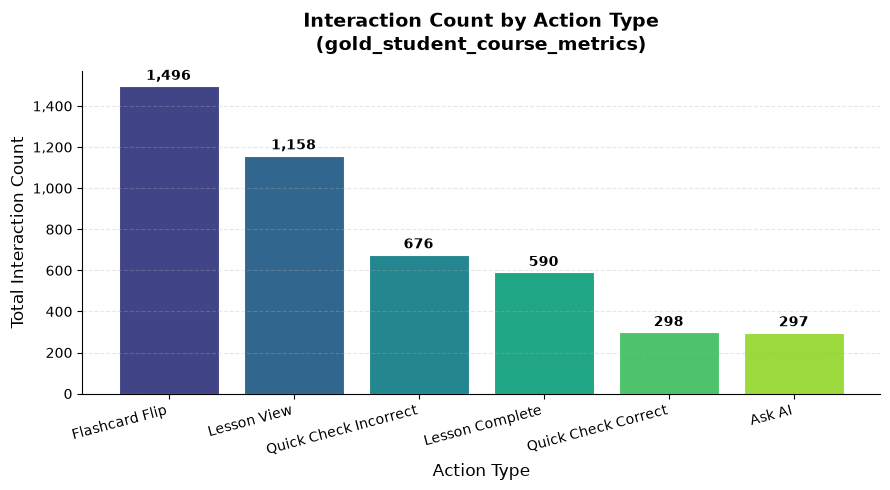

Chart saved to ../output/exploration_action_type_bar.png


In [4]:
df_metrics = tables['gold_student_course_metrics']
action_counts = pd.Series({
    'Lesson Complete': df_metrics['completed_lessons_count'].sum(),
    'Lesson View': df_metrics['viewed_lessons_count'].sum(),
    'Quick Check Correct': df_metrics['correct_checks_count'].sum(),
    'Quick Check Incorrect': df_metrics['incorrect_checks_count'].sum(),
    'Ask AI': df_metrics['ask_ai_count'].sum(),
    'Flashcard Flip': df_metrics['flashcard_flips_count'].sum()
}).sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(action_counts)))
bars = ax.bar(action_counts.index, action_counts.values, color=colors, edgecolor='white', linewidth=0.8)

for bar, val in zip(bars, action_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + action_counts.max() * 0.01,
            f'{val:,}', ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_title('Interaction Count by Action Type\n(gold_student_course_metrics)', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Action Type', fontsize=12)
ax.set_ylabel('Total Interaction Count', fontsize=12)
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.spines[['top', 'right']].set_visible(False)
ax.grid(axis='y', alpha=0.3, linestyle='--')
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.savefig('../output/exploration_action_type_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to ../output/exploration_action_type_bar.png')

## 4. Top-20 Nodes by Struggle Rate

Bar chart from `gold_concept_struggles` - highlights which knowledge nodes
students find most difficult.

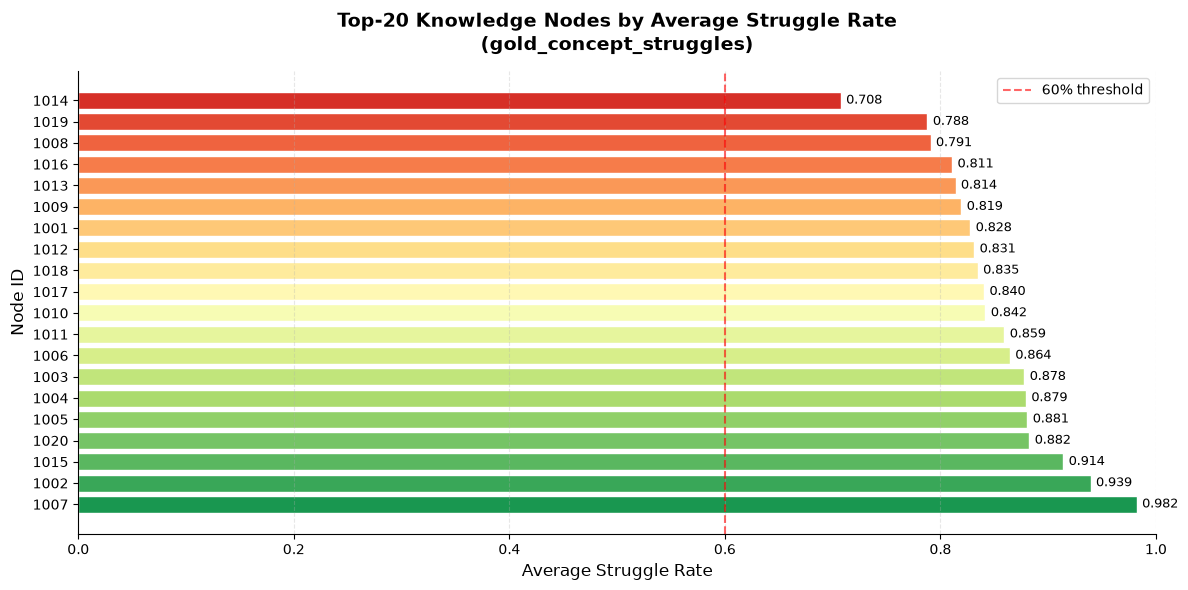

Chart saved to ../output/exploration_struggle_rate_bar.png


In [5]:
df_struggles = tables['gold_concept_struggles']

if 'node_id' in df_struggles.columns and 'struggle_rate' in df_struggles.columns:
    top_struggles = (
        df_struggles.groupby('node_id')['struggle_rate']
        .mean()
        .sort_values(ascending=False)
        .head(20)
    )

    fig, ax = plt.subplots(figsize=(12, 6))
    cmap = plt.cm.RdYlGn_r
    colors = [cmap(v) for v in np.linspace(0.1, 0.9, len(top_struggles))]
    bars = ax.barh(top_struggles.index.astype(str), top_struggles.values, color=colors, edgecolor='white')

    for bar, val in zip(bars, top_struggles.values):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=9)

    ax.set_title('Top-20 Knowledge Nodes by Average Struggle Rate\n(gold_concept_struggles)',
                 fontsize=14, fontweight='bold', pad=15)
    ax.set_xlabel('Average Struggle Rate', fontsize=12)
    ax.set_ylabel('Node ID', fontsize=12)
    ax.set_xlim(0, min(top_struggles.max() * 1.15, 1.0))
    ax.axvline(0.6, color='red', linestyle='--', alpha=0.6, label='60% threshold')
    ax.legend(fontsize=10)
    ax.spines[['top', 'right']].set_visible(False)
    ax.grid(axis='x', alpha=0.3, linestyle='--')
    plt.tight_layout()
    plt.savefig('../output/exploration_struggle_rate_bar.png', dpi=150, bbox_inches='tight')
    plt.show()
    print('Chart saved to ../output/exploration_struggle_rate_bar.png')
else:
    print('Expected columns not found in gold_concept_struggles')

## 5. Summary Statistics

In [6]:
print('=== BDC Lakehouse Summary Statistics ===')

# Unique users
users_sources = []
for t in ['gold_user_item_matrix', 'gold_student_course_metrics', 'gold_concept_struggles']:
    df = tables.get(t)
    if df is not None and 'user_id' in df.columns:
        users_sources.append(set(df['user_id'].unique()))
unique_users = len(set.union(*users_sources)) if users_sources else 0
print(f'Unique users (across all tables):  {unique_users:,}')

# Unique courses
courses_sources = []
for t in ['gold_student_course_metrics', 'gold_concept_struggles', 'gold_study_recommendations']:
    df = tables.get(t)
    if df is not None and 'course_id' in df.columns:
        courses_sources.append(set(df['course_id'].unique()))
unique_courses = len(set.union(*courses_sources)) if courses_sources else 0
print(f'Unique courses (across all tables): {unique_courses:,}')

# Unique nodes
nodes_sources = []
for t in ['gold_user_item_matrix', 'gold_concept_struggles', 'gold_struggle_alerts']:
    df = tables.get(t)
    if df is not None and 'node_id' in df.columns:
        nodes_sources.append(set(df['node_id'].unique()))
unique_nodes = len(set.union(*nodes_sources)) if nodes_sources else 0
print(f'Unique knowledge nodes:             {unique_nodes:,}')

# Total interactions
df_m = tables.get('gold_user_item_matrix')
if df_m is not None:
    total_interactions = df_m['interaction_count'].sum() if 'interaction_count' in df_m.columns else len(df_m)
    print(f'Total interaction events:           {int(total_interactions):,}')
    if 'implicit_affinity_score' in df_m.columns:
        print(f'Mean implicit affinity score:       {df_m["implicit_affinity_score"].mean():.4f}')

print()
print('Gold table sizes:')
for name, df in tables.items():
    print(f'  {name:<40}: {df.shape[0]:>6,} rows x {df.shape[1]} cols')

=== BDC Lakehouse Summary Statistics ===
Unique users (across all tables):  100
Unique courses (across all tables): 3
Unique knowledge nodes:             21
Total interaction events:           1,158
Mean implicit affinity score:       9.8875

Gold table sizes:
  gold_student_course_metrics             :    152 rows x 14 cols
  gold_concept_struggles                  :    290 rows x 7 cols
  gold_user_item_matrix                   :  1,158 rows x 6 cols
  gold_struggle_alerts                    :    291 rows x 6 cols
  gold_study_recommendations              :    152 rows x 6 cols
